In [ ]:
import os, json, time, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from scipy.stats import skew, kurtosis, entropy

from skimage.feature import graycomatrix, graycoprops, hog, local_binary_pattern
from skimage.filters import gabor

from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc, confusion_matrix

try:
    from xgboost import XGBClassifier
except ImportError:
    !pip install -q xgboost
    from xgboost import XGBClassifier

from google.colab import drive
drive.mount('/content/drive')

PROJECT = '/content/drive/MyDrive/oruntu_tanima_proje'
PREP_DIR    = os.path.join(PROJECT, 'veri_hazirlik')
METHOD3_DIR = os.path.join(PROJECT, 'yontemler', 'yontem3')
FEAT_DIR    = os.path.join(METHOD3_DIR, 'features')
GRAPHS_DIR  = os.path.join(METHOD3_DIR, 'grafikler')
os.makedirs(FEAT_DIR, exist_ok=True)
os.makedirs(GRAPHS_DIR, exist_ok=True)

# Reuse the same split_index.json => all 3000 labelled images
with open(os.path.join(PREP_DIR, 'split_index.json')) as f:
    split = json.load(f)

all_files, all_labels = [], []
for part in ['train', 'val', 'test']:
    for cls, label in [('yes', 1), ('no', 0)]:
        for rel in split[part][cls]:
            all_files.append(os.path.join(PROJECT, rel))
            all_labels.append(label)
all_labels = np.array(all_labels)
print(f'Total images: {len(all_files)}  yes={int(all_labels.sum())}  no={int(len(all_labels)-all_labels.sum())}')

Mounted at /content/drive
Total images: 3000  yes=1500  no=1500


In [ ]:
IMG_SIZE = 128

def load_gray(path, size=IMG_SIZE):
    img = Image.open(path).convert('L').resize((size, size))
    return np.array(img, dtype=np.uint8)

# 1. TEXTURE — GLCM (5 properties × 4 angles = 20)
def feat_glcm(img):
    glcm = graycomatrix(img, distances=[1], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                        levels=256, symmetric=True, normed=True)
    props = ['contrast', 'homogeneity', 'energy', 'correlation', 'ASM']
    return np.concatenate([graycoprops(glcm, p).flatten() for p in props])

# 2. SHAPE — Hu Moments (7), log-scaled for numerical stability
def feat_hu(img):
    m = cv2.moments(img)
    hu = cv2.HuMoments(m).flatten()
    return -np.sign(hu) * np.log10(np.abs(hu) + 1e-30)

# 3. STATISTICAL — Histogram (32 bins) + 5 moments = 37
def feat_stats(img):
    hist, _ = np.histogram(img, bins=32, range=(0, 256), density=True)
    flat = img.flatten().astype(np.float64)
    moments = np.array([flat.mean(), flat.std(),
                        skew(flat), kurtosis(flat),
                        entropy(hist + 1e-12)])
    return np.concatenate([hist, moments])

# 4. EDGE — HOG (kept compact: 8 px/cell, 2×2 cells/block, 9 orientations)
def feat_hog(img):
    return hog(img, orientations=9, pixels_per_cell=(16, 16),
               cells_per_block=(2, 2), feature_vector=True)

# 5. FREQUENCY — Gabor filter bank (4 freqs × 4 angles × 2 stats = 32)
def feat_gabor(img):
    feats = []
    for freq in [0.1, 0.2, 0.3, 0.4]:
        for theta in [0, np.pi/4, np.pi/2, 3*np.pi/4]:
            real, _ = gabor(img, frequency=freq, theta=theta)
            feats.extend([real.mean(), real.std()])
    return np.array(feats)

# 6. LOCAL PATTERN — LBP uniform histogram (P=8, R=1 -> 10 bins)
def feat_lbp(img):
    lbp = local_binary_pattern(img, P=8, R=1, method='uniform')
    hist, _ = np.histogram(lbp, bins=10, range=(0, 10), density=True)
    return hist

EXTRACTORS = [
    ('GLCM (texture)',      feat_glcm),
    ('Hu Moments (shape)',  feat_hu),
    ('Stats (intensity)',   feat_stats),
    ('HOG (edge)',          feat_hog),
    ('Gabor (frequency)',   feat_gabor),
    ('LBP (local)',         feat_lbp),
]

# Probe dimensions with one image
probe = load_gray(all_files[0])
print(f'Probe image shape: {probe.shape}, dtype={probe.dtype}\n')

print('=== Handcrafted feature dimensions ===')
dim_summary = []
running_total = 0
for name, fn in EXTRACTORS:
    v = fn(probe)
    dim_summary.append({'method': name, 'dim': len(v)})
    running_total += len(v)
    print(f'  {name:25s} -> {len(v):5d}')
print(f'  {"TOTAL (concatenated)":25s} -> {running_total:5d}')

pd.DataFrame(dim_summary + [{'method': 'TOTAL', 'dim': running_total}]).to_csv(
    os.path.join(FEAT_DIR, 'fe_dimensions.csv'), index=False)
print(f'\nSaved: features/fe_dimensions.csv')

Probe image shape: (128, 128), dtype=uint8

=== Handcrafted feature dimensions ===
  GLCM (texture)            ->    20
  Hu Moments (shape)        ->     7
  Stats (intensity)         ->    37
  HOG (edge)                ->  1764
  Gabor (frequency)         ->    32
  LBP (local)               ->    10
  TOTAL (concatenated)      ->  1870

Saved: features/fe_dimensions.csv


In [ ]:
def extract_all(image_paths):
    rows = []
    t0 = time.perf_counter()
    for i, p in enumerate(image_paths):
        img = load_gray(p)
        parts = [fn(img) for _, fn in EXTRACTORS]
        rows.append(np.concatenate(parts))
        if (i + 1) % 300 == 0:
            print(f'  {i+1}/{len(image_paths)} done ({time.perf_counter()-t0:.1f}s elapsed)')
    return np.vstack(rows), time.perf_counter() - t0

print('Extracting handcrafted features for 3000 images...')
X_handcrafted, elapsed = extract_all(all_files)
print(f'\nFinal shape: {X_handcrafted.shape}')
print(f'Total extraction time: {elapsed:.1f}s ({elapsed/60:.1f} min)')

np.save(os.path.join(FEAT_DIR, 'feat_handcrafted_all.npy'), X_handcrafted)
np.save(os.path.join(FEAT_DIR, 'labels.npy'), all_labels)
print(f'Saved features and labels to: {FEAT_DIR}')

Extracting handcrafted features for 3000 images...
  300/3000 done (255.1s elapsed)
  600/3000 done (505.5s elapsed)
  900/3000 done (751.0s elapsed)
  1200/3000 done (998.3s elapsed)
  1500/3000 done (1242.2s elapsed)
  1800/3000 done (1486.9s elapsed)
  2100/3000 done (1729.7s elapsed)
  2400/3000 done (1977.4s elapsed)
  2700/3000 done (2227.3s elapsed)
  3000/3000 done (2477.2s elapsed)

Final shape: (3000, 1870)
Total extraction time: 2477.2s (41.3 min)
Saved features and labels to: /content/drive/MyDrive/oruntu_tanima_proje/yontemler/yontem3/features


In [ ]:
# Reload labels from disk (the y variable got overwritten somewhere)
y = np.load(os.path.join(FEAT_DIR, 'labels.npy'))
X = np.load(os.path.join(FEAT_DIR, 'feat_handcrafted_all.npy'))
print('X.shape:', X.shape, ' y.shape:', y.shape)
assert X.shape[0] == y.shape[0] == 3000, 'mismatch'
print('OK, reloaded.')

X.shape: (3000, 1870)  y.shape: (3000,)
OK, reloaded.


In [ ]:
# Build slice indices for each handcrafted method (from the order in EXTRACTORS)
probe = load_gray(all_files[0])
slice_ranges = {}
start = 0
for name, fn in EXTRACTORS:
    dim = len(fn(probe))
    slice_ranges[name] = (start, start + dim)
    start += dim

print('Slice ranges per method:')
for name, (s, e) in slice_ranges.items():
    print(f'  {name:25s}  [{s:>5}:{e:<5}]  dim={e-s}')
print(f'  TOTAL feature dim: {start}  (should match X.shape[1]={X.shape[1]})')
assert start == X.shape[1]

# Run 6 methods × 5 ML = 30 combinations on 5-Fold CV
ablation_results = []
print('\nRunning ablation: 6 handcrafted × 5 ML = 30 combinations\n')

for method_name, (s, e) in slice_ranges.items():
    X_method = X[:, s:e]
    print(f'>>> {method_name}  features: {X_method.shape}')
    for ml_name, pipe in ML_MODELS.items():
        t0 = time.perf_counter()
        cvres = cross_validate(clone(pipe), X_method, y, cv=cv, scoring=SCORING,
                                n_jobs=-1, return_train_score=False)
        elapsed = time.perf_counter() - t0
        row = {
            'Method':       method_name,
            'ML':           ml_name,
            'Feature dim':  e - s,
            'Accuracy':     cvres['test_accuracy'].mean(),
            'Precision':    cvres['test_precision'].mean(),
            'Recall':       cvres['test_recall'].mean(),
            'F1':           cvres['test_f1'].mean(),
            'F1 Macro':     cvres['test_f1_macro'].mean(),
            'F1 Weighted':  cvres['test_f1_weighted'].mean(),
            'ROC-AUC':      cvres['test_roc_auc'].mean(),
            'Total (s)':    elapsed,
        }
        ablation_results.append(row)
        print(f'  {ml_name:22s}  acc={row["Accuracy"]:.4f}  f1={row["F1"]:.4f}  '
              f'auc={row["ROC-AUC"]:.4f}  t={elapsed:.1f}s')

df_ablation = pd.DataFrame(ablation_results)
csv_path = os.path.join(METHOD3_DIR, 'ablation_per_method.csv')
df_ablation.to_csv(csv_path, index=False)
print(f'\nSaved: {csv_path}')
print(f'Total combinations: {len(df_ablation)}')

Slice ranges per method:
  GLCM (texture)             [    0:20   ]  dim=20
  Hu Moments (shape)         [   20:27   ]  dim=7
  Stats (intensity)          [   27:64   ]  dim=37
  HOG (edge)                 [   64:1828 ]  dim=1764
  Gabor (frequency)          [ 1828:1860 ]  dim=32
  LBP (local)                [ 1860:1870 ]  dim=10
  TOTAL feature dim: 1870  (should match X.shape[1]=1870)

Running ablation: 6 handcrafted × 5 ML = 30 combinations

>>> GLCM (texture)  features: (3000, 20)
  SVM (RBF)               acc=0.7547  f1=0.7702  auc=0.8323  t=21.8s
  Random Forest           acc=0.9450  f1=0.9455  auc=0.9838  t=16.8s
  XGBoost                 acc=0.9500  f1=0.9501  auc=0.9789  t=2.6s
  KNN (k=5)               acc=0.8913  f1=0.8902  auc=0.9571  t=0.2s
  Logistic Regression     acc=0.6947  f1=0.7044  auc=0.7572  t=0.2s
>>> Hu Moments (shape)  features: (3000, 7)
  SVM (RBF)               acc=0.8297  f1=0.8268  auc=0.9005  t=3.8s
  Random Forest           acc=0.9733  f1=0.9735  auc=0.9

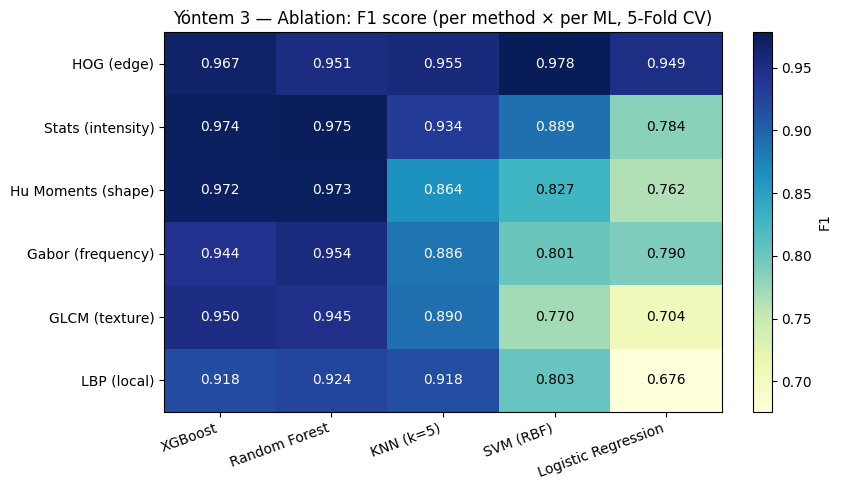

Saved: /content/drive/MyDrive/oruntu_tanima_proje/yontemler/yontem3/grafikler/method3_ablation_heatmap_f1.png


In [ ]:
pivot = df_ablation.pivot(index='Method', columns='ML', values='F1')
# Order rows by max F1 desc (best method on top), columns by mean F1 desc
pivot = pivot.loc[pivot.max(axis=1).sort_values(ascending=False).index]
pivot = pivot[pivot.mean(axis=0).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(8.5, 5))
im = ax.imshow(pivot.values, cmap='YlGnBu', aspect='auto')

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=20, ha='right')
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)

vmin, vmax = pivot.values.min(), pivot.values.max()
mid = (vmin + vmax) / 2
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        v = pivot.values[i, j]
        ax.text(j, i, f'{v:.3f}', ha='center', va='center',
                color='white' if v > mid else 'black', fontsize=10)

ax.set_title('Yöntem 3 — Ablation: F1 score (per method × per ML, 5-Fold CV)')
fig.colorbar(im, ax=ax, fraction=0.046, label='F1')
plt.tight_layout()
out = os.path.join(GRAPHS_DIR, 'method3_ablation_heatmap_f1.png')
plt.savefig(out, dpi=120, bbox_inches='tight'); plt.show()
print(f'Saved: {out}')

=== Best ML per handcrafted method ===
            Method            ML  Feature dim  Accuracy     F1  ROC-AUC  Total (s)
       LBP (local) Random Forest           10    0.9227 0.9238   0.9721     7.8023
    GLCM (texture)       XGBoost           20    0.9500 0.9501   0.9789     2.5569
 Gabor (frequency) Random Forest           32    0.9533 0.9538   0.9872    14.1267
Hu Moments (shape) Random Forest            7    0.9733 0.9735   0.9955     8.0512
 Stats (intensity) Random Forest           37    0.9753 0.9755   0.9963    14.2497
        HOG (edge)     SVM (RBF)         1764    0.9780 0.9782   0.9973   154.3045


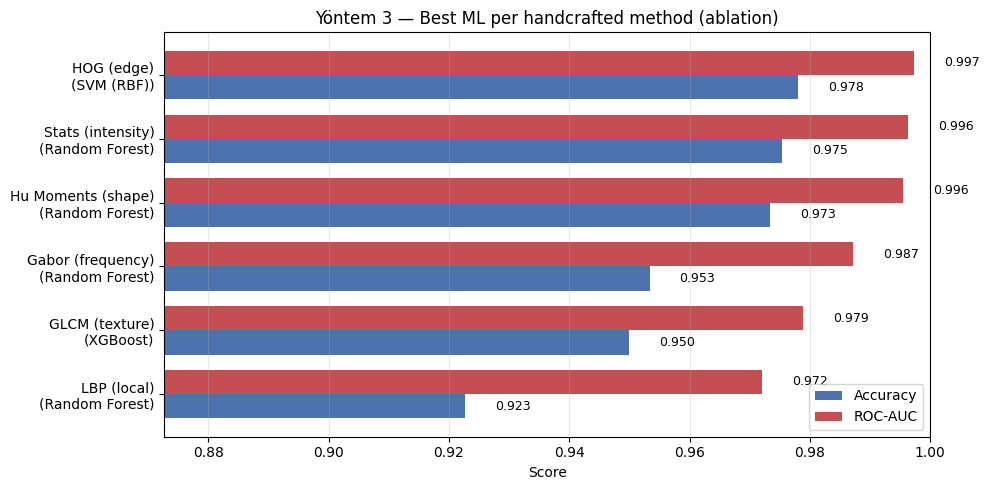

Saved: /content/drive/MyDrive/oruntu_tanima_proje/yontemler/yontem3/grafikler/method3_ablation_best_per_method.png


In [ ]:
best_per_method = (df_ablation.sort_values('F1', ascending=False)
                              .groupby('Method').head(1)
                              .sort_values('F1', ascending=True))

print('=== Best ML per handcrafted method ===')
print(best_per_method[['Method', 'ML', 'Feature dim',
                       'Accuracy', 'F1', 'ROC-AUC', 'Total (s)']].to_string(index=False))

y_pos = np.arange(len(best_per_method))
acc = best_per_method['Accuracy'].values
auc_ = best_per_method['ROC-AUC'].values
labels_y = [f"{m}\n({ml})" for m, ml in zip(best_per_method['Method'], best_per_method['ML'])]
h = 0.38

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(y_pos - h/2, acc,  h, label='Accuracy', color='#4C72B0')
ax.barh(y_pos + h/2, auc_, h, label='ROC-AUC',  color='#C44E52')
for i, v in enumerate(acc):  ax.text(v + 0.005, i - h/2, f'{v:.3f}', va='center', fontsize=9)
for i, v in enumerate(auc_): ax.text(v + 0.005, i + h/2, f'{v:.3f}', va='center', fontsize=9)
ax.set_yticks(y_pos); ax.set_yticklabels(labels_y)
ax.set_xlim(min(acc.min(), auc_.min()) - 0.05, 1.0)
ax.set_xlabel('Score')
ax.set_title('Yöntem 3 — Best ML per handcrafted method (ablation)')
ax.legend(loc='lower right'); ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
out = os.path.join(GRAPHS_DIR, 'method3_ablation_best_per_method.png')
plt.savefig(out, dpi=120, bbox_inches='tight'); plt.show()
print(f'Saved: {out}')

Best ablation combo: HOG (edge) + SVM (RBF)
  Acc=0.9780  F1=0.9782  AUC=0.9973


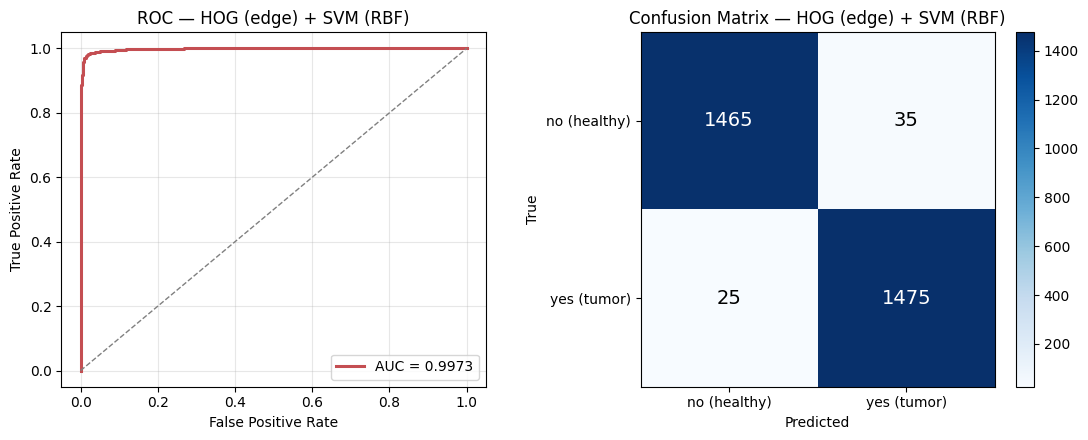

Saved: /content/drive/MyDrive/oruntu_tanima_proje/yontemler/yontem3/grafikler/method3_ablation_best_HOG_SVM_(RBF)_roc_cm.png

Confusion matrix [TN FP / FN TP]:
[[1465   35]
 [  25 1475]]
FN=25/1500  FP=35/1500


In [ ]:
best_ab = df_ablation.sort_values(['F1', 'ROC-AUC'], ascending=False).iloc[0]
best_method = best_ab['Method']
best_ml_ab  = best_ab['ML']
s, e = slice_ranges[best_method]
print(f'Best ablation combo: {best_method} + {best_ml_ab}')
print(f'  Acc={best_ab["Accuracy"]:.4f}  F1={best_ab["F1"]:.4f}  AUC={best_ab["ROC-AUC"]:.4f}')

X_best_ab = X[:, s:e]
pipe_ab = clone(ML_MODELS[best_ml_ab])

y_proba = cross_val_predict(pipe_ab, X_best_ab, y, cv=cv, method='predict_proba')[:, 1]
y_pred  = (y_proba >= 0.5).astype(int)

fpr, tpr, _ = roc_curve(y, y_proba)
roc_auc = auc(fpr, tpr)
cm = confusion_matrix(y, y_pred)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.5))
axL.plot(fpr, tpr, color='#C44E52', lw=2.2, label=f'AUC = {roc_auc:.4f}')
axL.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
axL.set_xlabel('False Positive Rate'); axL.set_ylabel('True Positive Rate')
axL.set_title(f'ROC — {best_method} + {best_ml_ab}')
axL.legend(loc='lower right'); axL.grid(alpha=0.3)

im = axR.imshow(cm, cmap='Blues')
axR.set_xticks([0, 1], ['no (healthy)', 'yes (tumor)'])
axR.set_yticks([0, 1], ['no (healthy)', 'yes (tumor)'])
axR.set_xlabel('Predicted'); axR.set_ylabel('True')
axR.set_title(f'Confusion Matrix — {best_method} + {best_ml_ab}')
thresh = cm.max() / 2
for i in range(2):
    for j in range(2):
        axR.text(j, i, cm[i, j], ha='center', va='center',
                 color='white' if cm[i, j] > thresh else 'black', fontsize=14)
fig.colorbar(im, ax=axR, fraction=0.046)
plt.tight_layout()
out = os.path.join(GRAPHS_DIR, f'method3_ablation_best_{best_method.split()[0]}_{best_ml_ab.replace(" ","_")}_roc_cm.png')
plt.savefig(out, dpi=120, bbox_inches='tight'); plt.show()
print(f'Saved: {out}')
print(f'\nConfusion matrix [TN FP / FN TP]:\n{cm}')
print(f'FN={cm[1,0]}/1500  FP={cm[0,1]}/1500')